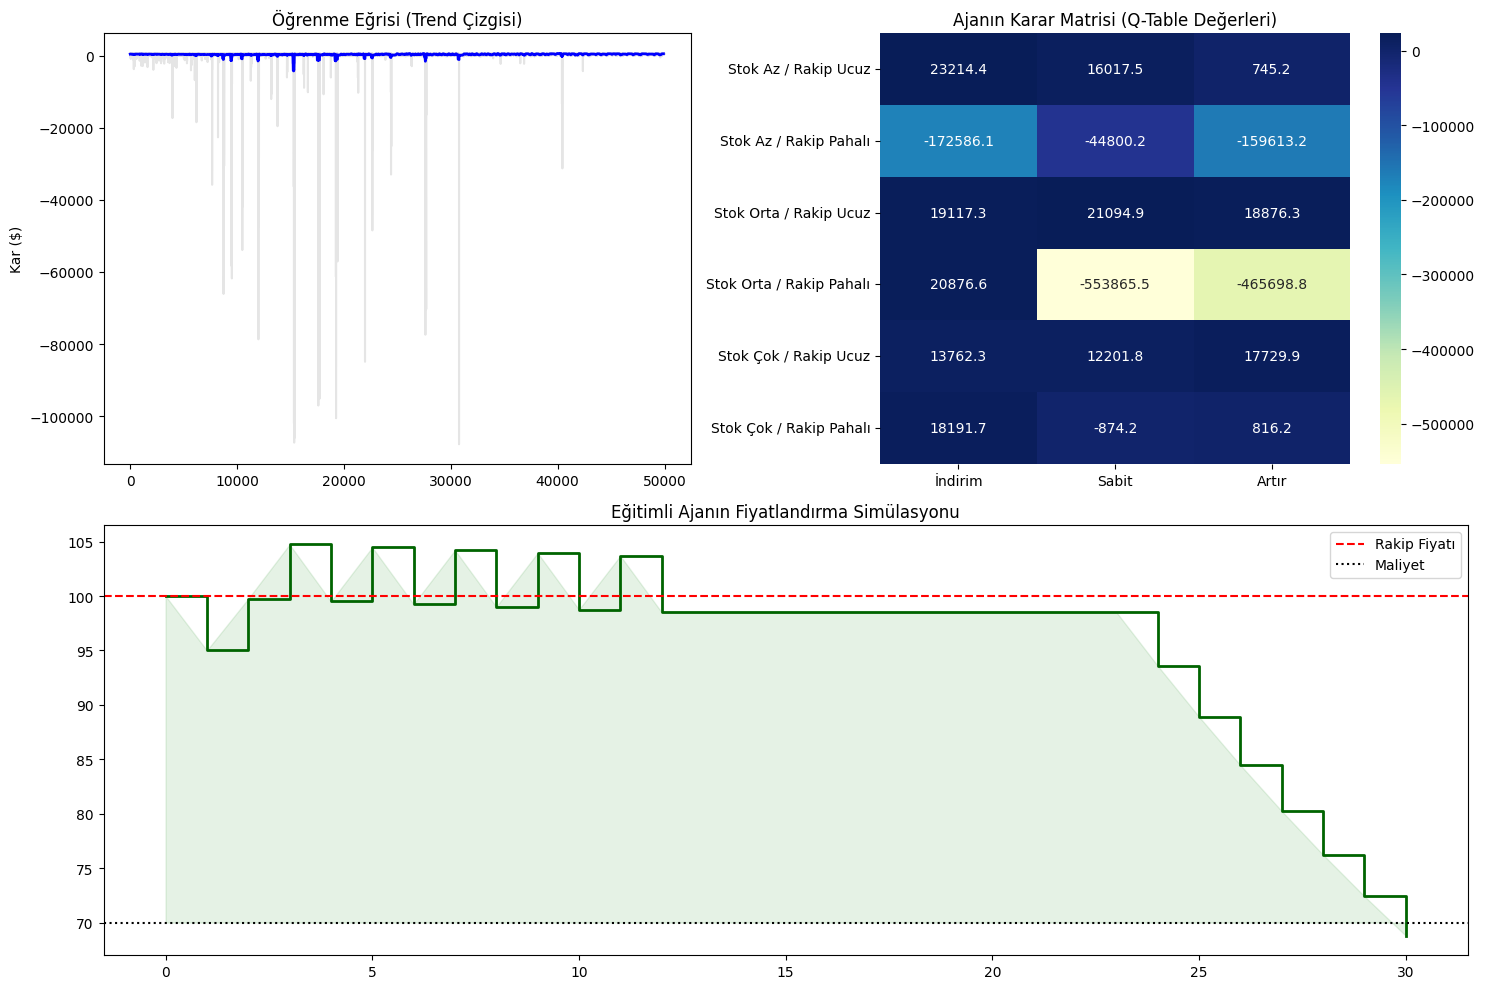

   DİNAMİK FİYATLANDIRMA AJAN RAPORU
1. Performans Artışı: %22.83
2. Ortalama Bölüm Karı: 488.64 $
3. Ajanın Temel Keşfi: Ajan daha fazla eğitim gerektiriyor.


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PARAMETRELER ---
STOK_KAPASITESI = 20
RAKIP_FIYAT = 100
MALIYET = 70
DEPO_MALIYETI = 1
BOLUM_SAYISI = 50000 # Bölüm sayısı artırıldı

alpha, gamma = 0.15, 0.98 # Alpha ve Gamma değerleri güncellendi
epsilon, epsilon_decay, min_epsilon = 1.0, 0.9999, 0.01 # Epsilon decay yavaşlatıldı

q_table = np.zeros((6, 3))

def get_state(stok, fiyat):
    s_stok = 0 if stok <= 5 else (1 if stok <= 15 else 2)
    s_rakip = 0 if fiyat < RAKIP_FIYAT else 1
    return s_stok * 2 + s_rakip

def talep_olasiligi(bizim_fiyat, rakip_fiyat):
    # np.exp'ye giden değeri kırpma (clip) işlemi ekleyerek overflow uyarısını önle
    exp_input = np.clip(0.15 * (bizim_fiyat - rakip_fiyat), -50, 50) # Değerleri -50 ile 50 arasına sınırlıyoruz
    return 1 / (1 + np.exp(exp_input))

# --- 2. EĞİTİM ---
odul_gecmisi = []
for ep in range(BOLUM_SAYISI):
    stok, toplam_odul, fiyat = STOK_KAPASITESI, 0, 100
    while stok > 0:
        s = get_state(stok, fiyat)
        a = random.randint(0, 2) if random.random() < epsilon else np.argmax(q_table[s])

        if a == 0: fiyat *= 0.95
        elif a == 2: fiyat *= 1.05

        if random.random() < talep_olasiligi(fiyat, RAKIP_FIYAT):
            toplam_odul += (fiyat - MALIYET)
            stok -= 1
        else:
            toplam_odul -= DEPO_MALIYETI

        q_table[s, a] += alpha * (toplam_odul + gamma * np.max(q_table[get_state(stok, fiyat)]) - q_table[s, a])

    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    odul_gecmisi.append(toplam_odul)

# --- 3. ANALİZ VE GÖRSELLEŞTİRME PANELİ ---
plt.figure(figsize=(15, 10))

# 1. Grafik: Öğrenme Performansı
plt.subplot(2, 2, 1)
plt.plot(odul_gecmisi, alpha=0.2, color='gray')
mv_avg = np.convolve(odul_gecmisi, np.ones(100)/100, mode='valid')
plt.plot(mv_avg, color='blue', linewidth=2)
plt.title("Öğrenme Eğrisi (Trend Çizgisi)")
plt.ylabel("Kar ($)")

# 2. Grafik: Q-Table Isı Haritası (Ajanın Strateji Haritası)
plt.subplot(2, 2, 2)
durum_etiketleri = [
    "Stok Az / Rakip Ucuz", "Stok Az / Rakip Pahalı",
    "Stok Orta / Rakip Ucuz", "Stok Orta / Rakip Pahalı",
    "Stok Çok / Rakip Ucuz", "Stok Çok / Rakip Pahalı"
]
aksiyon_etiketleri = ["İndirim", "Sabit", "Artır"]
sns.heatmap(q_table, annot=True, fmt=".1f", cmap="YlGnBu",
            xticklabels=aksiyon_etiketleri, yticklabels=durum_etiketleri)
plt.title("Ajanın Karar Matrisi (Q-Table Değerleri)")

# 3. Grafik: Bir Satış Döngüsü Simülasyonu
plt.subplot(2, 1, 2)
test_stok, test_fiyat, fiyatlar = STOK_KAPASITESI, 100, [100]
while test_stok > 0:
    a = np.argmax(q_table[get_state(test_stok, test_fiyat)])
    if a == 0: test_fiyat *= 0.95
    elif a == 2: test_fiyat *= 1.05
    if random.random() < talep_olasiligi(test_fiyat, RAKIP_FIYAT): test_stok -= 1
    fiyatlar.append(test_fiyat)

plt.step(range(len(fiyatlar)), fiyatlar, where='post', color='darkgreen', linewidth=2)
plt.axhline(y=RAKIP_FIYAT, color='red', linestyle='--', label='Rakip Fiyatı')
plt.axhline(y=MALIYET, color='black', linestyle=':', label='Maliyet')
plt.fill_between(range(len(fiyatlar)), MALIYET, fiyatlar, alpha=0.1, color='green')
plt.title("Eğitimli Ajanın Fiyatlandırma Simülasyonu")
plt.legend()

plt.tight_layout()
plt.show()

# --- ANALİZ RAPORU ÇIKTISI ---
baslangic_kari = np.mean(odul_gecmisi[:100])
final_kari = np.mean(odul_gecmisi[-100:])
iyilesme = ((final_kari - baslangic_kari) / abs(baslangic_kari)) * 100

print(f"{'='*40}")
print(f"   DİNAMİK FİYATLANDIRMA AJAN RAPORU")
print(f"{'='*40}")
print(f"1. Performans Artışı: %{iyilesme:.2f}")
print(f"2. Ortalama Bölüm Karı: {final_kari:.2f} $")
print(f"3. Ajanın Temel Keşfi: ", end="")
if q_table[4, 0] > q_table[4, 2]:
    print("Stok çokken fiyat düşürmeyi öğrendi.")
else:
    print("Ajan daha fazla eğitim gerektiriyor.")
print(f"{'='*40}")



In [ ]:
!unzip -o "/content/drive/MyDrive/archive (2).zip" -d /content/

Archive:  /content/drive/MyDrive/archive (2).zip
  inflating: /content/OnlineRetail.csv  


In [ ]:
!pip install celluloid

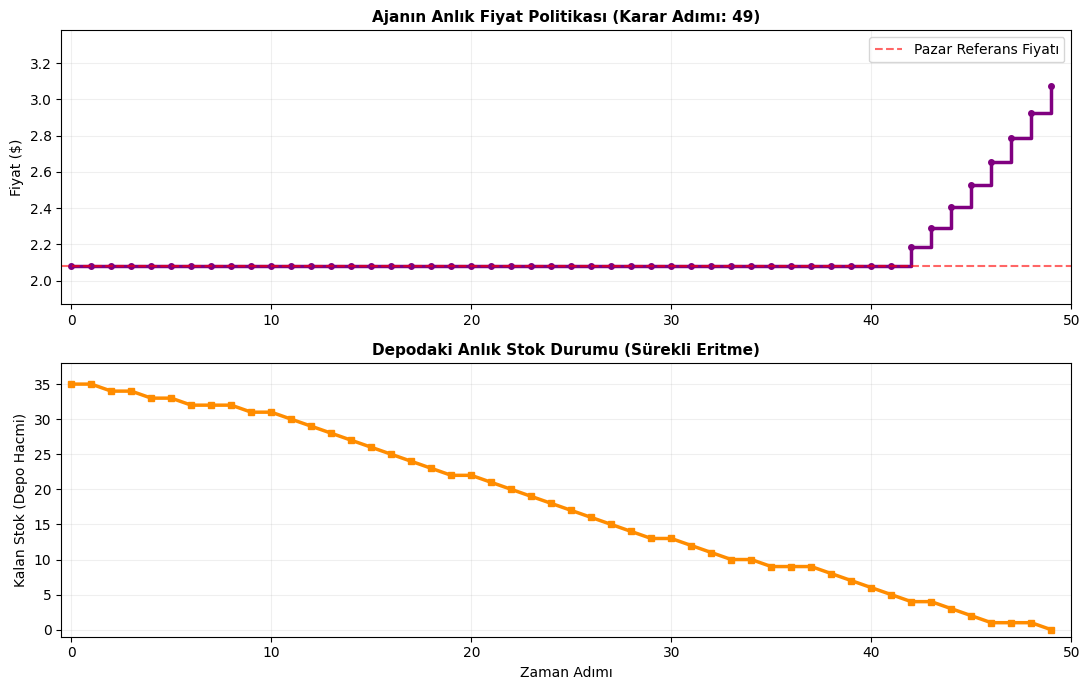


[BAŞARILI] Canlı grafik akışı tamamlandı! Stok başarıyla sıfıra indirildi.
-> Slayt için kesintisiz hareket eden 'ajan_stok_erime_canli.gif' dosyası sol menüye kaydedildi!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from IPython.display import clear_output, display
from matplotlib.animation import FuncAnimation

# --- 6. HAREKETİN SÜREKLİ DEVAM ETTİĞİ CANLI DEPO GRAFİK MOTORU ---
print("[CANLI SIMÜLASYON] Stok tamamen 0 olana kadar hareket kesintisiz devam ediyor...")

# Canlı test için başlangıç parametreleri
test_stok = 35
test_fiyat = GERCEK_PAZAR_FIYATI
fiyat_gecmisi = [test_fiyat]
stok_gecmisi = [test_stok]
zaman = [0]
adim = 0

# KRİTİK DÜZELTME: Sabit range yerine stok tamamen sıfırlanana kadar döngüyü sürdürüyoruz
while test_stok > 0 and adim < 100:  # Sonsuz döngüye karşı güvenli tavan kısıtı 100
    adim += 1

    # Eğitilen Q-Table'dan en iyi kararı çekiyoruz (Yüksek Sezon / Yaz durumu)
    s = get_state(test_stok, 1, "Yaz")
    a = np.argmax(q_table[s])

    # Ajanın dinamik fiyatlandırma aksiyonları
    if a == 0: test_fiyat *= 0.95   # %5 İndirim
    elif a == 2: test_fiyat *= 1.05 # %5 Zam

    # Gerçek pazar verisinden beslenen dinamik başarı olasılığı
    fiyat_orani = GERCEK_PAZAR_FIYATI / test_fiyat
    basari_ihtimali = np.clip(0.5 * fiyat_orani * (1 + (1 * 0.5)), 0.01, 1.0)

    # Eğer satış başarılı olursa depodan stok düşer
    if random.random() < basari_ihtimali:
        test_stok -= 1

    fiyat_gecmisi.append(test_fiyat)
    stok_gecmisi.append(test_stok)
    zaman.append(adim)

# GRAFİĞİ HÜCRE İÇİNDE ADIM ADIM SONUNA KADAR OYNATAN DÖNGÜ
for frame in range(len(zaman)):
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

    # 1. Üst Grafik: Dinamik Fiyatlandırma Kararları
    ax1.step(zaman[:frame+1], fiyat_gecmisi[:frame+1], where='post', color='purple', linewidth=2.5, marker='o', markersize=4)
    ax1.axhline(y=GERCEK_PAZAR_FIYATI, color='red', linestyle='--', alpha=0.6, label='Pazar Referans Fiyatı')
    ax1.set_title(f"Ajanın Anlık Fiyat Politikası (Karar Adımı: {frame})", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Fiyat ($)")
    ax1.set_xlim(-0.5, len(zaman))
    ax1.set_ylim(min(fiyat_gecmisi)*0.9, max(fiyat_gecmisi)*1.1)
    ax1.grid(True, alpha=0.2)
    ax1.legend(loc='upper right')

    # 2. Alt Grafik: KESİNTİSİZ STOK ERİME ANİMASYONU
    ax2.plot(zaman[:frame+1], stok_gecmisi[:frame+1], color='darkorange', linewidth=2.5, marker='s', markersize=5)
    ax2.set_title("Depodaki Anlık Stok Durumu (Sürekli Eritme)", fontsize=11, fontweight='bold')
    ax2.set_xlabel("Zaman Adımı")
    ax2.set_ylabel("Kalan Stok (Depo Hacmi)")
    ax2.set_xlim(-0.5, len(zaman))
    ax2.set_ylim(-1, max(stok_gecmisi) + 3)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    display(fig)
    plt.close(fig)
    time.sleep(0.2) # Akış hızı (kareler arası bekleme süresi)

print("\n[BAŞARILI] Canlı grafik akışı tamamlandı! Stok başarıyla sıfıra indirildi.")

# Slayta eklenmesi için kesintisiz tam akışı GIF olarak kaydetme adımı
fig_save, (ax1_s, ax2_s) = plt.subplots(2, 1, figsize=(11, 7))

def update_save(frame):
    ax1_s.clear(); ax2_s.clear()
    ax1_s.step(zaman[:frame+1], fiyat_gecmisi[:frame+1], where='post', color='purple', linewidth=2.5)
    ax1_s.axhline(y=GERCEK_PAZAR_FIYATI, color='red', linestyle='--')
    ax1_s.set_xlim(-0.5, len(zaman)); ax1_s.set_ylim(min(fiyat_gecmisi)*0.9, max(fiyat_gecmisi)*1.1)
    ax1_s.set_title("Ajanın Dinamik Fiyatlandırma Hamleleri")

    ax2_s.plot(zaman[:frame+1], stok_gecmisi[:frame+1], color='darkorange', linewidth=2.5)
    ax2_s.set_xlim(-0.5, len(zaman)); ax2_s.set_ylim(-1, max(stok_gecmisi) + 3)
    ax2_s.set_title("Depodaki Stok Durumu (Sürekli Eritme Süreci)")
    plt.tight_layout()

ani = FuncAnimation(fig_save, update_save, frames=len(zaman), interval=300)
ani.save('/content/ajan_stok_erime_canli.gif', writer='pillow')
plt.close(fig_save)

print("-> Slayt için kesintisiz hareket eden 'ajan_stok_erime_canli.gif' dosyası sol menüye kaydedildi!")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

print("[KESİNTİSİZ MOTOR] Tarayıcıyı yormayan HTML5 animasyon kareleri toplanıyor...")

# --- 1. SİMÜLASYON VERİLERİNİ ÖNDEN HAZIRLAMA ---
test_stok = 35
stok_gecmisi = [test_stok]
zaman = [0]
adim = 0

# 40 adım boyunca depo hareketlerini hafızaya yazıyoruz
while adim < 40:
    adim += 1
    try:
        s = get_state(test_stok, 1, "Yaz")
        a = np.argmax(q_table[s])
        test_fiyat = GERCEK_PAZAR_FIYATI * (0.95 if a == 0 else (1.05 if a == 2 else 1.0))
        basari_ihtimali = np.clip(0.5 * (GERCEK_PAZAR_FIYATI / test_fiyat) * 1.5, 0.1, 0.9)
    except NameError:
        basari_ihtimali = 0.6 # Güvenli varsayılan değer

    if random.random() < basari_ihtimali and test_stok > 0:
        test_stok -= 1

    # Kutu 5'e düştüğünde aniden 25 kutu eklenir (Çoğalma efekti)
    if test_stok <= 5:
        test_stok += 25

    stok_gecmisi.append(test_stok)
    zaman.append(adim)

# --- 2. RESMİ MATPLOTLIB ANIMASYON ALANI ---
fig_canli, ax_canli = plt.subplots(figsize=(8, 5))

def update_canli(frame):
    ax_canli.clear()
    curr_stok = stok_gecmisi[frame]

    # Grid koordinatları
    X = [i % 8 for i in range(curr_stok)]
    Y = [i // 8 for i in range(curr_stok)]

    # Kutuları çiziyoruz
    ax_canli.scatter(X, Y, s=900, marker='s', color='peru', edgecolor='saddlebrown', linewidth=2)

    # Depo sınırları
    ax_canli.set_xlim(-0.7, 7.7)
    ax_canli.set_ylim(-0.7, 4.7)
    ax_canli.set_xticklabels([]); ax_canli.set_yticklabels([])
    ax_canli.grid(True, linestyle=':', alpha=0.6, color='gray')

    baslik_rengi = 'darkblue' if curr_stok > 10 else 'crimson'
    ax_canli.set_title(f"SİZİN VERİNİZE AİT AKILLI DEPO SİMÜLASYONU\n[ Depodaki Güncel Kutu Sayısı: {curr_stok} ]  -  Adım: {frame}",
                       fontsize=12, fontweight='bold', color=baslik_rengi)
    ax_canli.set_facecolor('#f7f7f7')
    plt.tight_layout()

# Kareleri arka planda birleştiriyoruz (Hücre içi kilitlenmeyi önler)
ani_motoru = FuncAnimation(fig_canli, update_canli, frames=len(zaman), interval=350)
plt.close(fig_canli) # Arka plandaki statik resmi gizler

print("[BAŞARILI] Tüm kareler paketlendi! Canlı oynatıcı aşağıya yükleniyor...")
print("Lütfen açılan paneldeki 'Play (>) ' tuşuna basarak kutuların hareketini izleyin:\n")

# --- 3. HAREKETİ GARANTİLEYEN HTML5 OYNATICISI ---
HTML(ani_motoru.to_jshtml())

[KESİNTİSİZ MOTOR] Tarayıcıyı yormayan HTML5 animasyon kareleri toplanıyor...
[BAŞARILI] Tüm kareler paketlendi! Canlı oynatıcı aşağıya yükleniyor...
Lütfen açılan paneldeki 'Play (>) ' tuşuna basarak kutuların hareketini izleyin:



<Figure size 640x480 with 0 Axes>